# Group analysis of columns data

## Load data

In [1]:
import os

### This is to analyse the data in group
import numpy as np
import pandas as pd
from numexpr.necompiler import default_type

# Import columns data
csv_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/'
subject_list = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/code/subjects_valid.txt'
subject_group = r'/Users/bass/Desktop/HanwenLin/AD_DECODE_data3.xlsx'

# Read subject_list to get the subjects indexes
subjects = []
with open(subject_list, 'r') as f:
    for line in f:
        line = line.strip('\n')
        subjects.append(line)

print(subjects)

# Read subject_group to get subjects groups
ad_decode_data2 = pd.read_excel(subject_group, sheet_name='AD_DECODE_data2')
print('Size of the group data:', ad_decode_data2.shape)
print('Columns of the group data:', ad_decode_data2.columns)

type = 'rd'

['S04493', 'S03847', 'S02227', 'S02451', 'S02812', 'S02686', 'S03010', 'S02877', 'S00775', 'S02802', 'S02842', 'S03867', 'S02695', 'S01470', 'S02421', 'S03350', 'S02373', 'S03896', 'S02967', 'S02654', 'S02390', 'S02231', 'S03033', 'S02506', 'S03378', 'S02320', 'S02446', 'S02410', 'S02954', 'S02524', 'S01619', 'S02469', 'S02361', 'S03265', 'S02110', 'S02715', 'S03391', 'S03890', 'S02898', 'S03293', 'S02939', 'S02289', 'S04526', 'S04738', 'S02535', 'S02473', 'S02817', 'S03069', 'S03321', 'S02871', 'S02402', 'S02813', 'S02737', 'S02491', 'S02424', 'S03308', 'S02938', 'S02670', 'S03045', 'S02386', 'S02840', 'S02690', 'S03889', 'S02771', 'S02781', 'S02666', 'S03028', 'S02720', 'S03034', 'S01912', 'S03017', 'S02266', 'S02363', 'S02765', 'S01621', 'S03225', 'S03343', 'S02804', 'S02753', 'S02224', 'S02926', 'S02987', 'S02485', 'S01412']
Size of the group data: (123, 47)
Columns of the group data: Index(['Subject', 'MRI_Exam', 'age', 'genotype', 'sex', 'Risk', 'risk_for_ad',
       'ethnicity',

In [2]:
# Classified as left and right, risk 0 1 and 2 3, plot individual and averaged curves
# 4 categories in total
import matplotlib.pyplot as plt
import os

region_list = ['bankssts',
'caudalanteriorcingulate',
'caudalmiddlefrontal',
'cuneus',
'entorhinal',
'fusiform',
'inferiorparietal',
'inferiortemporal',
'isthmuscingulate',
'lateraloccipital',
'lateralorbitofrontal',
'lingual',
'medialorbitofrontal',
'middletemporal',
'parahippocampal',
'paracentral',
'parsopercularis',
'parsorbitalis',
'parstriangularis',
'pericalcarine',
'postcentral',
'posteriorcingulate',
'precentral',
'precuneus',
'rostralanteriorcingulate',
'rostralmiddlefrontal',
'superiorfrontal',
'superiorparietal',
'superiortemporal',
'supramarginal',
'frontalpole',
'temporalpole',
'transversetemporal',
'insula'
]
zero_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 0]['MRI_Exam'].tolist()
one_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 1]['MRI_Exam'].tolist()
two_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 2]['MRI_Exam'].tolist()
three_risk_sub = ad_decode_data2[ad_decode_data2['risk_for_ad'] == 3]['MRI_Exam'].tolist()
low_risk_sub = zero_risk_sub + one_risk_sub
high_risk_sub = two_risk_sub + three_risk_sub
print(len(low_risk_sub))
print(len(high_risk_sub))


83
11


In [3]:
left_low_dic = {region: np.empty([1, 21]) for region in region_list}
right_low_dic = {region: np.empty([1, 21]) for region in region_list}
rl_low_dic = {region: np.empty([1, 21]) for region in region_list}
left_high_dic = {region: np.empty([1, 21]) for region in region_list}
right_high_dic = {region: np.empty([1, 21]) for region in region_list}
rl_high_dic = {region: np.empty([1, 21]) for region in region_list}

def get_subject_id(s):
    integer = int(s)
    expected_length = 5
    length = len(str(integer))
    s_id = 'S'
    for i in range(expected_length - length):
        s_id = s_id + '0'
    s_id = s_id + str(integer)
    return s_id

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for subject in low_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        # Check if file exit
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            left_low_dic[region] = np.append(left_low_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            # Check if column contains NaN
            if column.isna().any().any():
                continue
            right_low_dic[region] = np.append(right_low_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_low_dic[region] = np.append(rl_low_dic[region], column.to_numpy(), axis=0)

for subject in high_risk_sub:
    subject_id = get_subject_id(subject)
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        rl_region_name = subject_id + '_rl_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        rl_csv = csv_dir + subject_id + '/columns_1mm/'+ rl_region_name
        if not os.path.exists(lh_csv):
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            left_high_dic[region] = np.append(left_high_dic[region], column.to_numpy(), axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            right_high_dic[region] = np.append(right_high_dic[region], column.to_numpy(), axis=0)
        with open(rl_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                continue
            rl_high_dic[region] = np.append(rl_high_dic[region], column.to_numpy(), axis=0)

for region in region_list:
    left_low_dic[region] = left_low_dic[region][1:]
    right_low_dic[region] = right_low_dic[region][1:]
    rl_low_dic[region] = rl_low_dic[region][1:]
    left_high_dic[region] = left_high_dic[region][1:]
    right_high_dic[region] = right_high_dic[region][1:]
    rl_high_dic[region] = rl_high_dic[region][1:]

In [4]:
# Plot the columns
from matplotlib.lines import Line2D
for region in region_list:
    plt.figure()
    for i in range(left_low_dic[region].shape[0]):
        plt.plot(range(21), left_low_dic[region][i], color='b', linewidth=0.1)
    for i in range(right_low_dic[region].shape[0]):
        plt.plot(range(21), right_low_dic[region][i], color='r', linewidth=0.1)
    for i in range(left_high_dic[region].shape[0]):
        plt.plot(range(21), left_high_dic[region][i], color='g', linewidth=0.1)
    for i in range(right_high_dic[region].shape[0]):
        plt.plot(range(21), right_high_dic[region][i], color='c', linewidth=0.1)
    plt.plot(range(21), np.mean(left_low_dic[region], axis=0), color='b', linewidth=2)
    plt.plot(range(21), np.mean(right_low_dic[region], axis=0), color='r', linewidth=2)
    plt.plot(range(21), np.mean(left_high_dic[region], axis=0), color='g', linewidth=2)
    plt.plot(range(21), np.mean(right_high_dic[region], axis=0), color='c', linewidth=2)
    legend_elements = [Line2D([0], [0], color='b', linewidth=0.1, label='left_low_individual'),
                       Line2D([0], [0], color='r', linewidth=0.1, label='right_low_individual'),
                       Line2D([0], [0], color='g', linewidth=0.1, label='left_high_individual'),
                       Line2D([0], [0], color='c', linewidth=0.1, label='right_high_individual'),
                       Line2D([0], [0], color='b', linewidth=2, label='left_low_mean'),
                       Line2D([0], [0], color='r', linewidth=2, label='right_low_mean'),
                       Line2D([0], [0], color='g', linewidth=2, label='left_high_mean'),
                       Line2D([0], [0], color='c', linewidth=2, label='right_high_mean')]
    plt.legend(handles=legend_elements)
    plt.title(region)
    plt.xticks([0, 21], ['WM/GM','Pial'])
    plt.ylabel(type)
    fig_dir = r'/Volumes/newJetStor/newJetStor/paros/paros_WORK/hanwen/ad_decode_test/output/linear_model_analysis/'
    plt.savefig(fig_dir + type + '_' + region + '.png')
    plt.close()


In [5]:
# Linear Model
valid_subjects = []
left_dic = {region: np.empty([1, 3]) for region in region_list}
right_dic = {region: np.empty([1, 3]) for region in region_list}
for subject in subjects:
    subject_id = subject
    file_valid = 'True'
    for region in region_list:
        lh_region_name = subject_id + '_lh_' + region + '_' + type + '.csv'
        rh_region_name = subject_id + '_rh_' + region + '_' + type + '.csv'
        lh_csv = csv_dir + subject_id + '/columns_1mm/'+ lh_region_name
        rh_csv = csv_dir + subject_id + '/columns_1mm/'+ rh_region_name
        if not os.path.exists(lh_csv):
            file_valid = 'False'
            continue
        with open(lh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            left_dic[region] = np.append(left_dic[region], three_bin, axis=0)
        with open(rh_csv, 'r') as f:
            column = pd.read_csv(f, dtype='float64', header=None)
            if column.isna().any().any():
                file_valid = 'False'
                continue
            three_bin = column.to_numpy()
            three_bin = np.array([[np.mean(three_bin[0, 0:7]), np.mean(three_bin[0, 7:14]), np.mean(three_bin[0, 14:])]])
            right_dic[region] = np.append(right_dic[region], three_bin, axis=0)
    if file_valid == 'True':
        valid_subjects.append(subject_id)

In [6]:
valid_subject_index = []
for subject in valid_subjects:
    subject = subject[1:]
    subject_index = int(subject)
    valid_subject_index.append(subject_index)
for region in region_list:
    right_dic[region] = right_dic[region][1:]
    left_dic[region] = left_dic[region][1:]

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
genotype_column = np.empty([0,1])
sex_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    genotype = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['genotype'].values[0]
    sex = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['sex'].values[0]
    if '4' in genotype:
        genotype = 1
    else:
        genotype = 0
    if sex == 'M':
        sex = 1
    else:
        sex = 0
    age_column = np.append(age_column, age)
    genotype_column = np.append(genotype_column, genotype)
    sex_column = np.append(sex_column, sex)

age_column = age_column.reshape((-1, 1))
genotype_column = genotype_column.reshape((-1, 1))
sex_column = sex_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Standard genotype
mu_genotype = np.mean(genotype_column)
sigma_genotype = np.std(genotype_column)
genotype_std = (genotype_column - mu_genotype) / sigma_genotype

# Standard sex
mu_sex = np.mean(sex_column)
sigma_sex = np.std(sex_column)
sex_std = (sex_column - mu_sex) / sigma_sex

# Combine features
X = np.column_stack((age_std, genotype_std, sex_std))
print(X)

[[ 0.67825758 -0.93189112 -0.85539892]
 [-2.12139645  1.07308674  1.16904519]
 [-1.02286429 -0.93189112  1.16904519]
 [-0.36858664 -0.93189112 -0.85539892]
 [ 1.0053964  -0.93189112  1.16904519]
 [-0.56486994  1.07308674 -0.85539892]
 [ 0.92034031 -0.93189112 -0.85539892]
 [-1.80799746  1.07308674 -0.85539892]
 [-1.41543087  1.07308674 -0.85539892]
 [ 0.52515662 -0.93189112 -0.85539892]
 [ 0.08940771  1.07308674 -0.85539892]
 [-0.65516025 -0.93189112  1.16904519]
 [-0.76115323 -0.93189112 -0.85539892]
 [ 1.66817966  1.07308674 -0.85539892]
 [ 1.9213851  -0.93189112 -0.85539892]
 [ 0.22026323  1.07308674  1.16904519]
 [-0.49944217  1.07308674 -0.85539892]
 [-2.06970851 -0.93189112  1.16904519]
 [-1.41543087 -0.93189112 -0.85539892]
 [-0.95743652 -0.93189112 -0.85539892]
 [ 0.8359385   1.07308674 -0.85539892]
 [-1.41543087 -0.93189112  1.16904519]
 [-0.69572547  1.07308674 -0.85539892]
 [ 0.74368535 -0.93189112 -0.85539892]
 [ 0.93996864  1.07308674  1.16904519]
 [ 0.54740206 -0.93189112

lh_bankssts
Weights:
[[ 0.0045874  -0.00039896  0.00474398]
 [ 0.00966387 -0.00130701  0.00593798]
 [ 0.06115278  0.00251189  0.01669333]]
MSE:
0.0019436064971011
R2:
0.22420386051119953


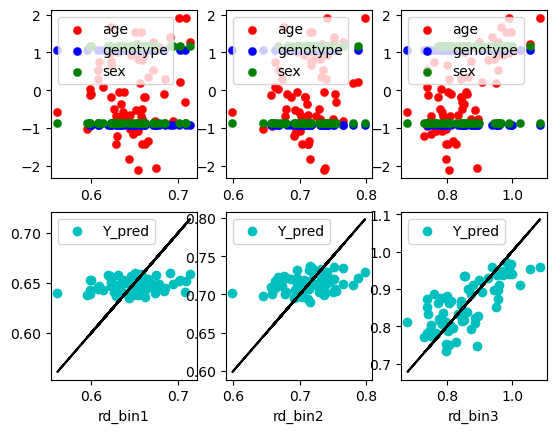

lh_caudalanteriorcingulate
lh_caudalmiddlefrontal
lh_cuneus
Weights:
[[ 0.00596099 -0.00151006 -0.00205344]
 [ 0.0125044  -0.0096772   0.01336059]
 [ 0.04597001 -0.00672283  0.04355358]]
MSE:
0.0032270554048874764
R2:
0.2063516884185819


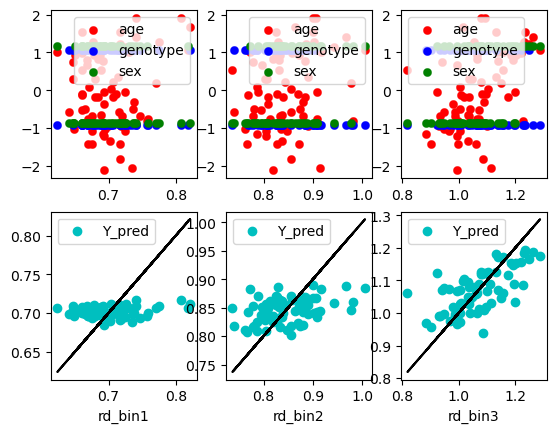

lh_entorhinal
lh_fusiform
Weights:
[[ 0.00520866  0.00075294 -0.00311222]
 [ 0.01936874  0.00058788  0.00093662]
 [ 0.06337615  0.00171536  0.00675933]]
MSE:
0.0017667058648425328
R2:
0.27602891601181195


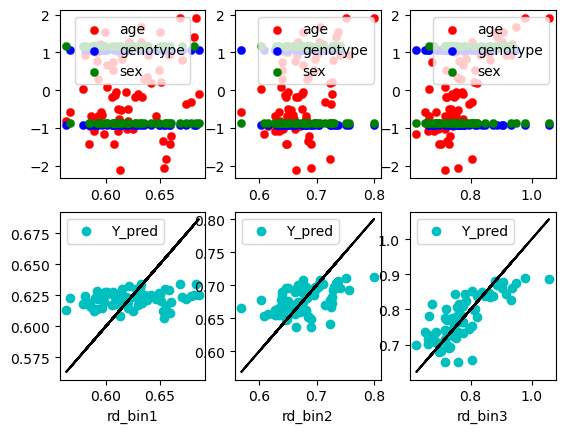

lh_inferiorparietal
Weights:
[[ 0.00275163 -0.00205196 -0.00060343]
 [ 0.01070316 -0.00309021 -0.00033588]
 [ 0.06103994 -0.00157677  0.01086539]]
MSE:
0.0018731252263794096
R2:
0.21267459440361783


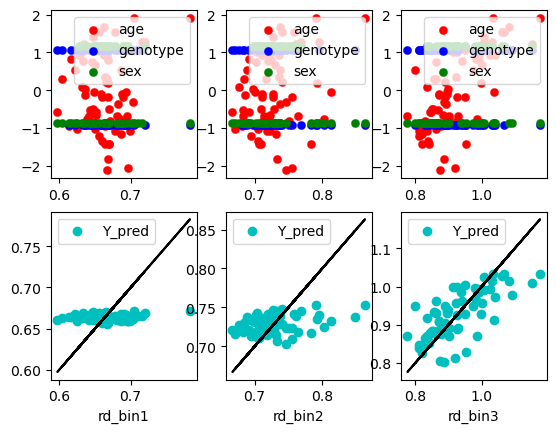

lh_inferiortemporal
Weights:
[[0.00895236 0.0012063  0.00326369]
 [0.01939181 0.00139534 0.00587421]
 [0.04883476 0.00069562 0.01096328]]
MSE:
0.002217485320586828
R2:
0.22206990313521716


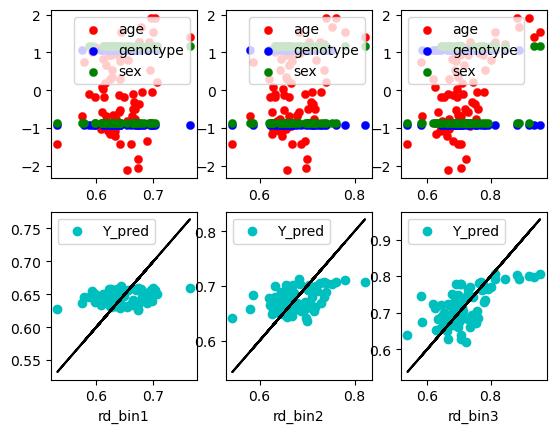

lh_isthmuscingulate
Weights:
[[ 0.01051668 -0.00382701  0.0074175 ]
 [ 0.02657662 -0.00217774  0.01201159]
 [ 0.05490211  0.00328223  0.01569314]]
MSE:
0.002738729562955779
R2:
0.28365375182550656


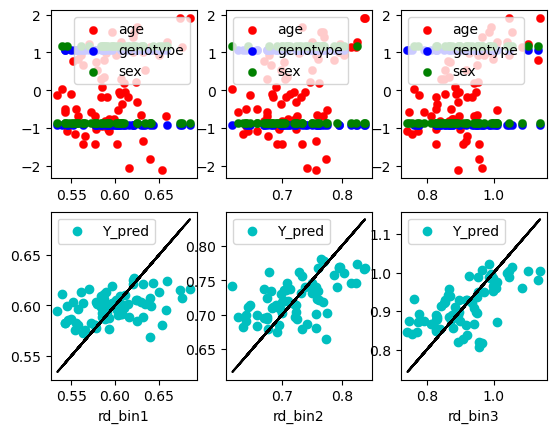

lh_lateraloccipital
Weights:
[[ 0.01817424  0.00659771 -0.00588588]
 [ 0.02771975  0.00222247  0.00798755]
 [ 0.04831292 -0.00230673  0.03526233]]
MSE:
0.00458520512332748
R2:
0.21928484142960658


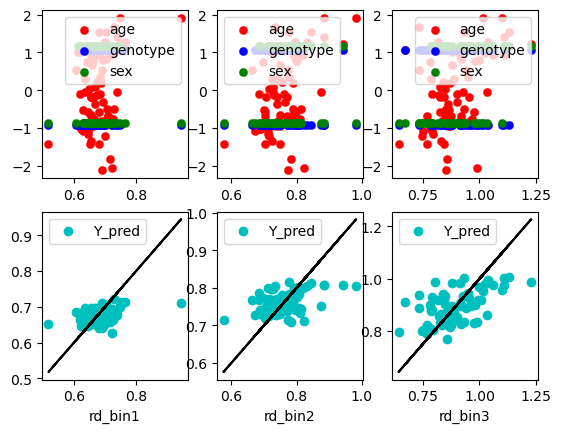

lh_lateralorbitofrontal
lh_lingual
Weights:
[[ 0.01419568 -0.00159366  0.00555229]
 [ 0.03238289 -0.00226779  0.01330104]
 [ 0.07024315  0.00127027  0.01807481]]
MSE:
0.00388515279966124
R2:
0.2806766569192547


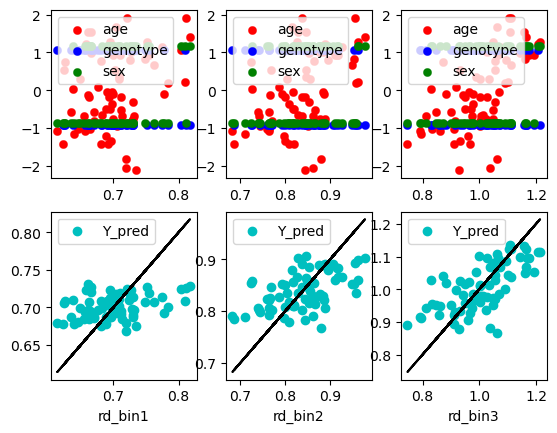

lh_medialorbitofrontal
lh_middletemporal
Weights:
[[ 0.00713515  0.00116053  0.00474531]
 [ 0.01565976 -0.00118902  0.00388606]
 [ 0.05910741 -0.00818004  0.00808249]]
MSE:
0.0017018381355464725
R2:
0.2719966336574074


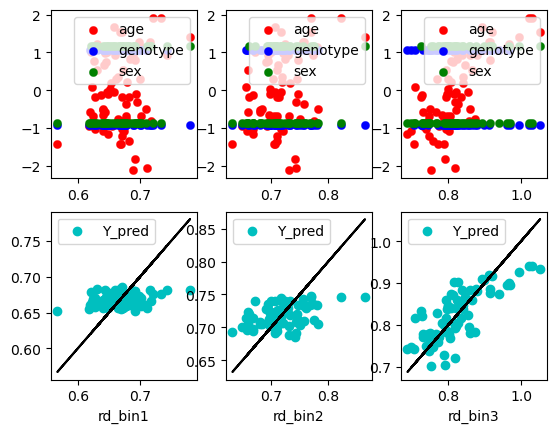

lh_parahippocampal
lh_paracentral
Weights:
[[ 0.00462214 -0.00734284  0.00367254]
 [ 0.01253744 -0.00768822  0.00806205]
 [ 0.05490585 -0.0171136   0.03621226]]
MSE:
0.0031393320491655435
R2:
0.2194775129593102


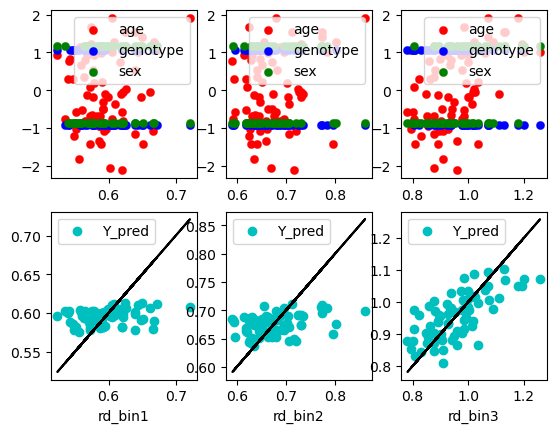

lh_parsopercularis
lh_parsorbitalis
lh_parstriangularis
lh_pericalcarine
Weights:
[[ 0.01953077 -0.00381389 -0.00273199]
 [ 0.03583372 -0.00665029  0.01519828]
 [ 0.06038071 -0.0001381   0.04305171]]
MSE:
0.004228387067483582
R2:
0.3119511367772165


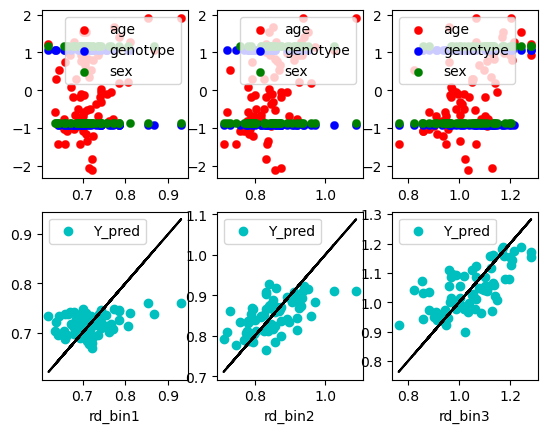

lh_postcentral
lh_posteriorcingulate
lh_precentral
lh_precuneus
Weights:
[[ 0.00424745 -0.00361592 -0.00148526]
 [ 0.01349587 -0.00666594  0.00116655]
 [ 0.05810737 -0.00301526  0.01216142]]
MSE:
0.0020526679243413133
R2:
0.22407363241079592


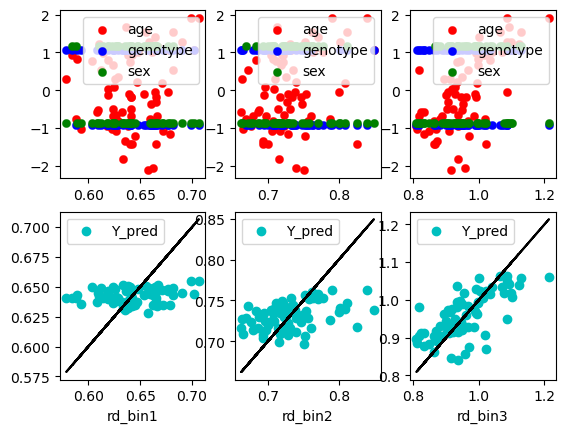

lh_rostralanteriorcingulate
lh_rostralmiddlefrontal
lh_superiorfrontal
lh_superiorparietal
lh_superiortemporal
lh_supramarginal
Weights:
[[ 0.00171412 -0.00644061  0.00102409]
 [ 0.01291614 -0.01024621 -0.00153445]
 [ 0.05904826 -0.00972955  0.00280785]]
MSE:
0.0019852858789651865
R2:
0.2471525250964021


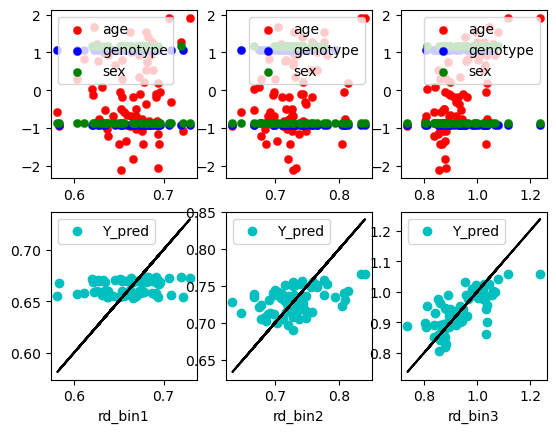

lh_frontalpole
lh_temporalpole
lh_transversetemporal
lh_insula


In [8]:
from sklearn.metrics import r2_score
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y = left_dic[region]
    linear_model = LinearRegression()
    linear_model.fit(X, Y)
    r2 = linear_model.score(X, Y)
    weights = linear_model.coef_
    Y_pred = linear_model.predict(X)
    mse = np.mean((Y_pred - Y) ** 2)

    if r2 > 0.2:
        print('Weights:')
        print(weights)
        print('MSE:')
        print(mse)
        print('R2:')
        print(r2)
        plt.subplot(2, 3, 1)
        plt.scatter(Y[:,0], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,0], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 4)
        plt.scatter(Y[:,0], Y_pred[:,0], label='Y_pred', color='c')
        plt.plot(Y[:,0], Y[:,0], color='k')
        plt.legend()
        plt.xlabel(type + '_bin1')
        plt.subplot(2, 3, 2)
        plt.scatter(Y[:,1], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,1], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 5)
        plt.scatter(Y[:,1], Y_pred[:,1], label='Y_pred', color='c')
        plt.plot(Y[:,1], Y[:,1], color='k')
        plt.legend()
        plt.xlabel(type + '_bin2')
        plt.subplot(2, 3, 3)
        plt.scatter(Y[:,2], X[:,0], label='age', color='r', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,1], label='genotype', color='b', linewidths=0.2)
        plt.scatter(Y[:,2], X[:,2], label='sex', color='g', linewidths=0.2)
        plt.legend()
        plt.subplot(2, 3, 6)
        plt.scatter(Y[:,2], Y_pred[:,2], label='Y_pred', color='c')
        plt.plot(Y[:,2], Y[:,2], color='k')
        plt.legend()
        plt.xlabel(type + '_bin3')
        plt.show()



In [9]:
# Construct X
X = np.empty([0,3])
age_column = np.empty([0,1])
# Collect features: age, genotype and sex
for subject in valid_subject_index:
    age = ad_decode_data2[ad_decode_data2['MRI_Exam'] == subject]['age'].values[0]
    age_column = np.append(age_column, age)

age_column = age_column.reshape((-1, 1))
# Standard age
scaler = StandardScaler()
age_std = scaler.fit_transform(age_column)

# Combine features
X = age_column
print(X)

[[63.        ]
 [20.21      ]
 [37.        ]
 [47.        ]
 [68.        ]
 [44.        ]
 [66.7       ]
 [25.        ]
 [31.        ]
 [60.66      ]
 [54.        ]
 [42.62      ]
 [41.        ]
 [78.13      ]
 [82.        ]
 [56.        ]
 [45.        ]
 [21.        ]
 [31.        ]
 [38.        ]
 [65.41      ]
 [31.        ]
 [42.        ]
 [64.        ]
 [67.        ]
 [61.        ]
 [36.92777778]
 [71.26      ]
 [40.        ]
 [44.        ]
 [76.        ]
 [81.65      ]
 [36.        ]
 [67.86      ]
 [72.        ]
 [44.78      ]
 [76.        ]
 [52.        ]
 [57.        ]
 [41.        ]
 [50.        ]
 [32.        ]
 [34.        ]
 [38.        ]
 [48.        ]
 [64.45      ]
 [53.        ]
 [65.        ]
 [45.        ]
 [42.        ]
 [51.        ]
 [58.        ]
 [50.88      ]
 [57.        ]
 [35.        ]
 [50.        ]
 [42.        ]
 [70.        ]
 [70.        ]
 [36.        ]
 [68.        ]
 [72.        ]
 [50.        ]
 [67.04      ]
 [69.        ]
 [52.        ]
 [69.     

lh_bankssts
Weights:
[[0.00031114]] [[0.00065308]] [[0.00400566]]
MSE:
0.0008826057556598731 0.001088920615764166 0.004200285707933735
R2:
0.024982080093957415 0.08382884195673057 0.47156284053054043


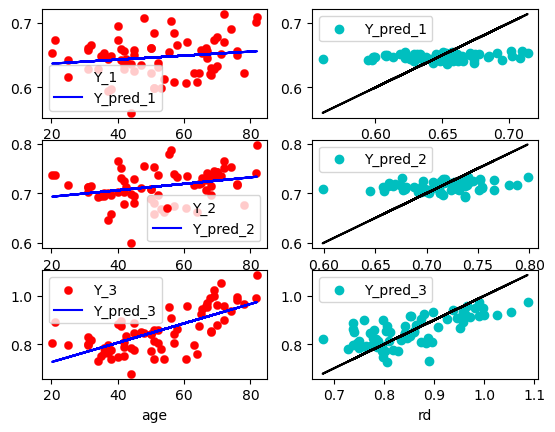

lh_caudalanteriorcingulate
Weights:
[[-0.00030813]] [[0.00036386]] [[0.00219552]]
MSE:
0.0015385846552402735 0.0016825005355739619 0.0035065468094205455
R2:
0.01421009861210809 0.018050460162877813 0.2430686355352003


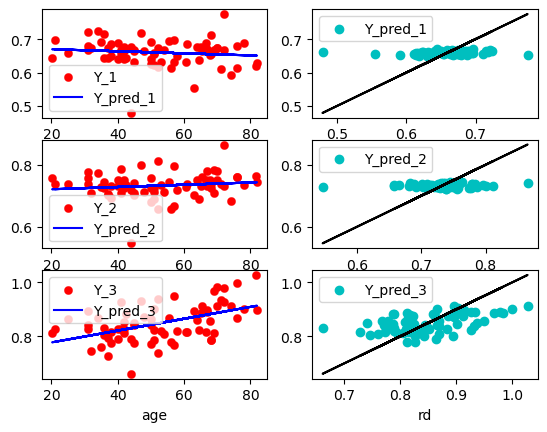

lh_caudalmiddlefrontal
Weights:
[[-9.63972609e-05]] [[0.00028381]] [[0.00304732]]
MSE:
0.0008962208576086439 0.0013708296237527446 0.003665583265844208
R2:
0.002416237117464415 0.013540601482569192 0.3717772877845502


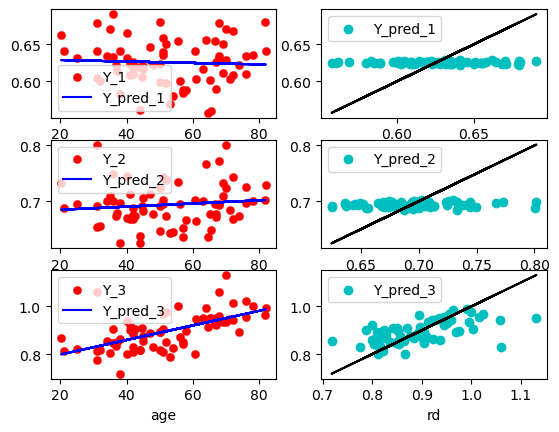

lh_cuneus
Weights:
[[0.00039991]] [[0.00092362]] [[0.00313532]]
MSE:
0.0015597742809689002 0.002970995699056332 0.007409939416446302
R2:
0.023392115410643677 0.06285846993067568 0.2365838049895993


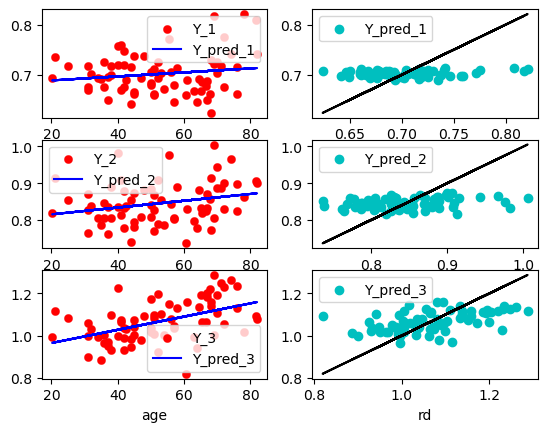

lh_entorhinal
Weights:
[[0.00033337]] [[0.0017832]] [[0.00345557]]
MSE:
0.005225673894872923 0.006581630080300783 0.008638777766829217
R2:
0.0049434206886198595 0.10141453937030054 0.24408310353181206


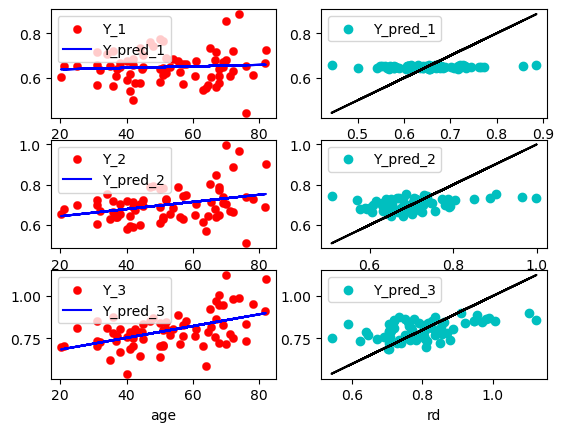

lh_fusiform
Weights:
[[0.0003293]] [[0.00126362]] [[0.00414233]]
MSE:
0.0008481647266412795 0.0012715819947434204 0.0032393819077025897
R2:
0.02899978153524041 0.22680437125534192 0.5530485613595785


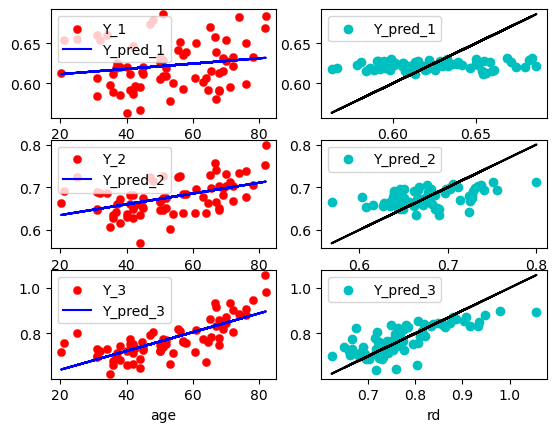

lh_inferiorparietal
Weights:
[[0.00019695]] [[0.00072667]] [[0.00402467]]
MSE:
0.0008589977366531325 0.0013040477628452694 0.003592259443838665
R2:
0.0104388098213275 0.08641864175161484 0.512988061624997


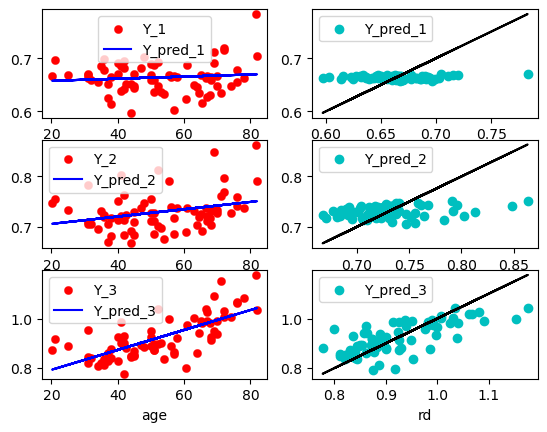

lh_inferiortemporal
Weights:
[[0.0005804]] [[0.00126592]] [[0.00320647]]
MSE:
0.0012504288502892672 0.0017534299175843272 0.0038156642260091414
R2:
0.05920539368832778 0.17593734937243577 0.386294734080747


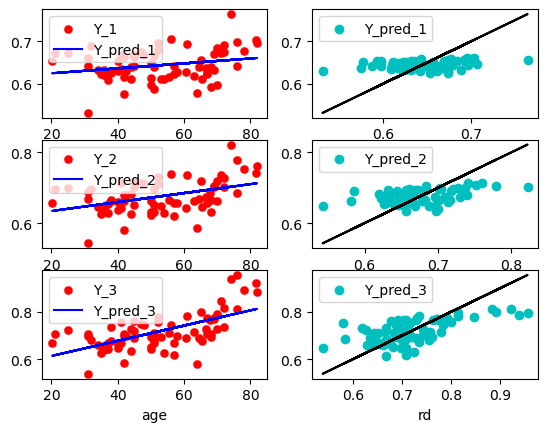

lh_isthmuscingulate
Weights:
[[0.00073318]] [[0.00177686]] [[0.0035884]]
MSE:
0.0011489541864765508 0.0021525688093744226 0.005389911247061924
R2:
0.09852531503284989 0.25519294948253013 0.3581842985521001


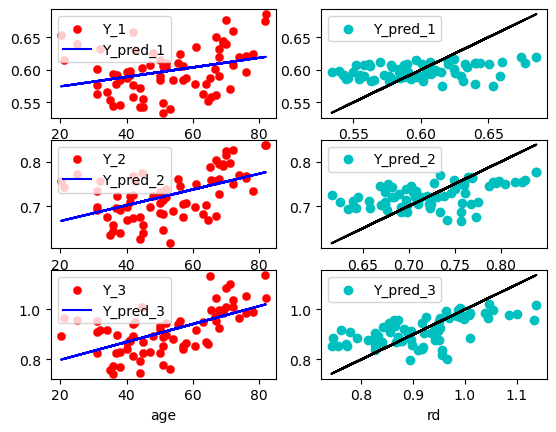

lh_lateraloccipital
Weights:
[[0.00112229]] [[0.00180694]] [[0.00323699]]
MSE:
0.0022887272527946367 0.0032957103563843225 0.009575493025078834
R2:
0.11391224307714609 0.18793400958874806 0.2035818837637331


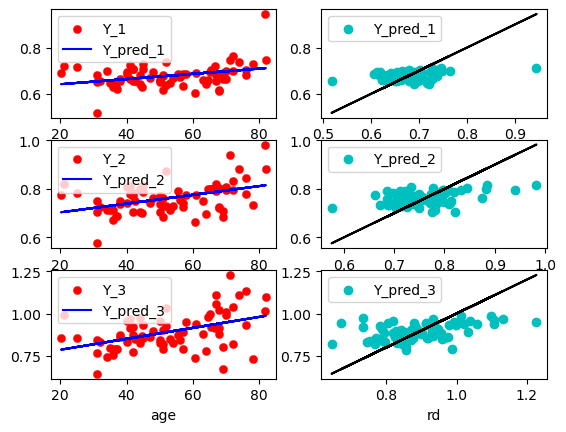

lh_lateralorbitofrontal
lh_lingual
Weights:
[[0.00095148]] [[0.00215958]] [[0.00461343]]
MSE:
0.001892170891814514 0.003604215378246981 0.006703962735900238
R2:
0.10053037434913381 0.23211345477118606 0.42582835606119795


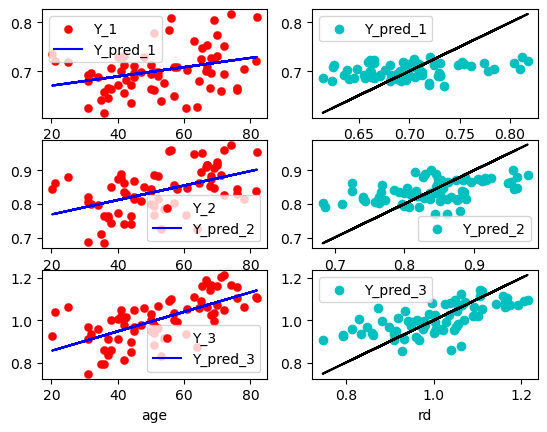

lh_medialorbitofrontal
lh_middletemporal
Weights:
[[0.00046425]] [[0.0010411]] [[0.00395134]]
MSE:
0.0010977314976552278 0.0013891479519357846 0.00279657606025939
R2:
0.04385340566215867 0.15416890882484136 0.5660064461071319


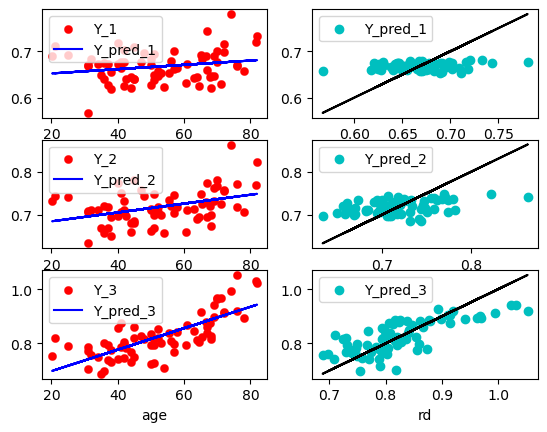

lh_parahippocampal
Weights:
[[0.00051831]] [[0.00125189]] [[0.00317516]]
MSE:
0.0018887242134269049 0.0027632001831475587 0.003834100493482145
R2:
0.03215860924560543 0.1169933545059173 0.3805167804568399


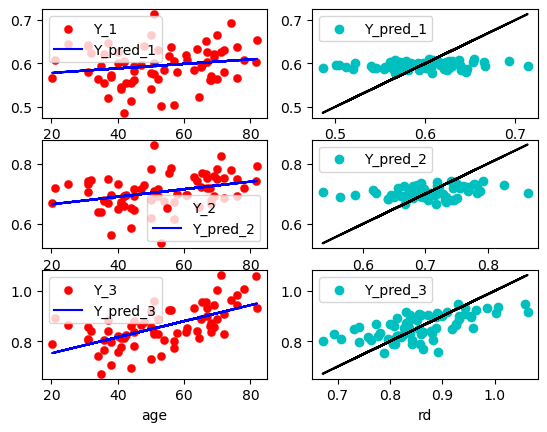

lh_paracentral
Weights:
[[0.00037221]] [[0.00090005]] [[0.00379885]]
MSE:
0.0013922491036440232 0.002727457568171457 0.0071578811524718
R2:
0.022716926155796457 0.0648816087467241 0.3201782468767337


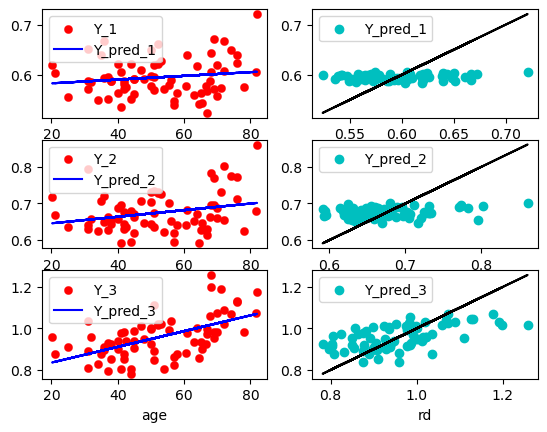

lh_parsopercularis
Weights:
[[-0.00013276]] [[0.00033041]] [[0.0027516]]
MSE:
0.0005705043191222286 0.0012213941981738022 0.003264821357080721
R2:
0.007165244808923332 0.020452505008247135 0.3513805283155004


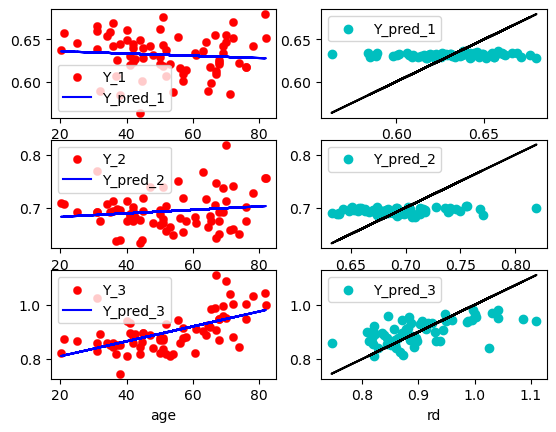

lh_parsorbitalis
Weights:
[[0.00053027]] [[0.00078214]] [[0.00242574]]
MSE:
0.002255746380839827 0.0029725222735261176 0.004071699419189726
R2:
0.028295041853660496 0.045869793796704306 0.25238676352358747


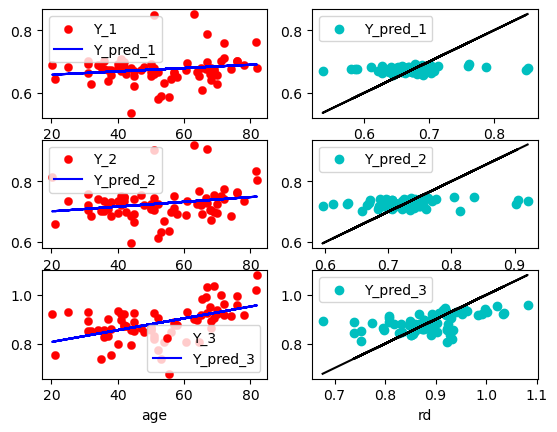

lh_parstriangularis
Weights:
[[0.00021686]] [[0.00063221]] [[0.00300548]]
MSE:
0.0012411830703041103 0.0014482829350283308 0.003705751827840178
R2:
0.00877325490690084 0.060564331001049854 0.3628190996870996


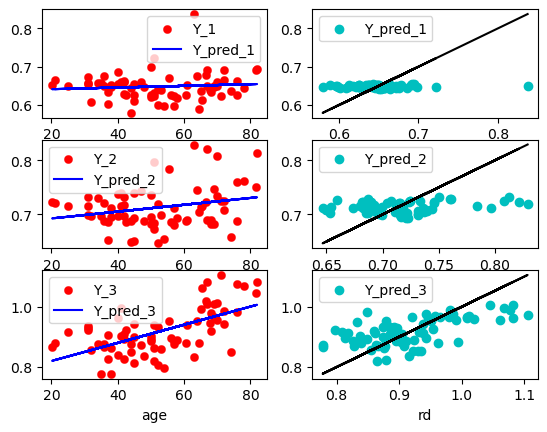

lh_pericalcarine
Weights:
[[0.00130675]] [[0.00242655]] [[0.00402001]]
MSE:
0.0024948379132231817 0.0033764136964448688 0.008972131166205701
R2:
0.13784866703735565 0.2894586469731204 0.29615176545747546


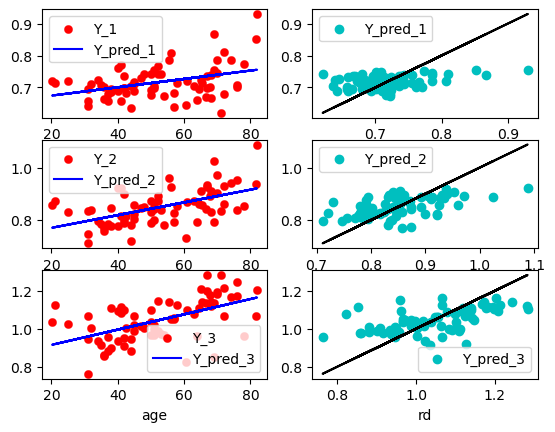

lh_postcentral
Weights:
[[-0.00010368]] [[0.00057673]] [[0.00307045]]
MSE:
0.0021851954184497193 0.004393782416340271 0.007530662076445249
R2:
0.0011479029635853566 0.017376788974857504 0.2262737486084313


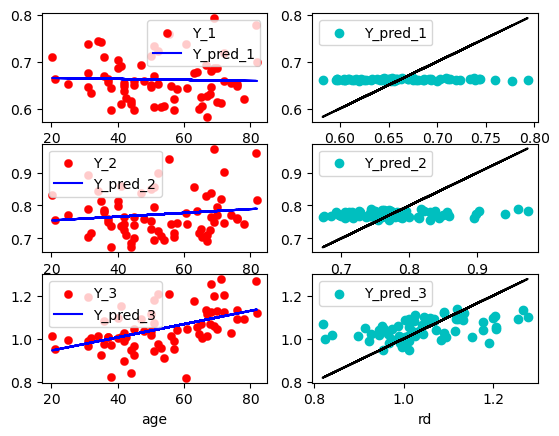

lh_posteriorcingulate
Weights:
[[-0.0002997]] [[0.00029071]] [[0.00274503]]
MSE:
0.0008647032165204445 0.0012500907990420694 0.004649266903508027
R2:
0.023690947053501055 0.015547612337562522 0.2746284826617672


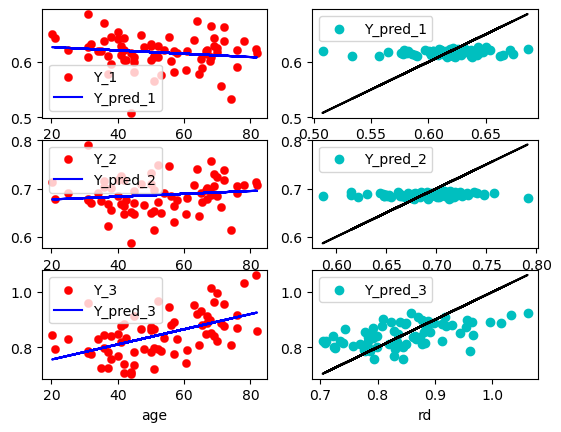

lh_precentral
lh_precuneus
Weights:
[[0.00030705]] [[0.00094293]] [[0.00384738]]
MSE:
0.0007626082977292567 0.0015222160135557397 0.004093942095987892
R2:
0.02806882488408724 0.12006241864964506 0.45788458197684745


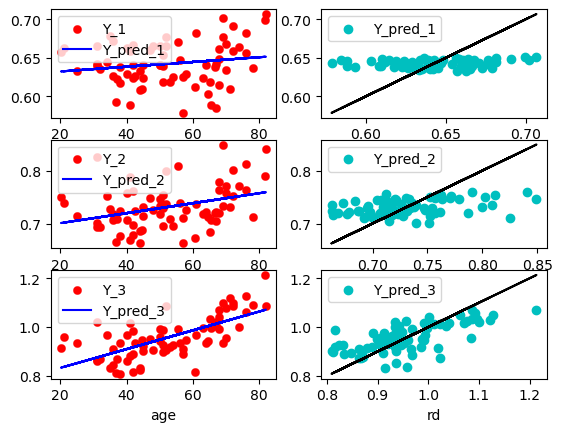

lh_rostralanteriorcingulate
lh_rostralmiddlefrontal
Weights:
[[-4.87478603e-05]] [[0.00030812]] [[0.00265276]]
MSE:
0.0008522910289361859 0.0012830648946593416 0.0034402463344815086
R2:
0.0006509029835635172 0.016990794072822224 0.3233372722151099


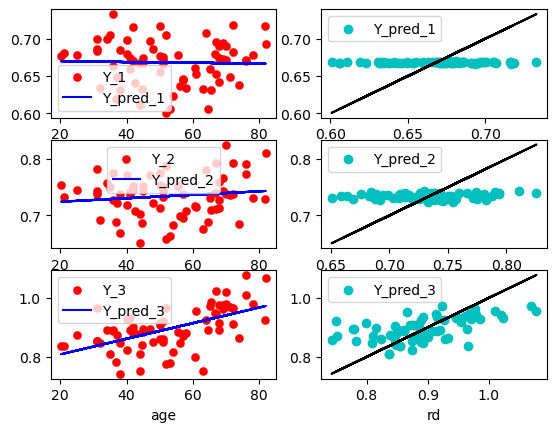

lh_superiorfrontal
Weights:
[[-0.00012333]] [[0.00027786]] [[0.00228602]]
MSE:
0.0008872418973894453 0.0015868375156210704 0.0034800123577904585
R2:
0.003988444473138286 0.011237591094921506 0.25969598124917714


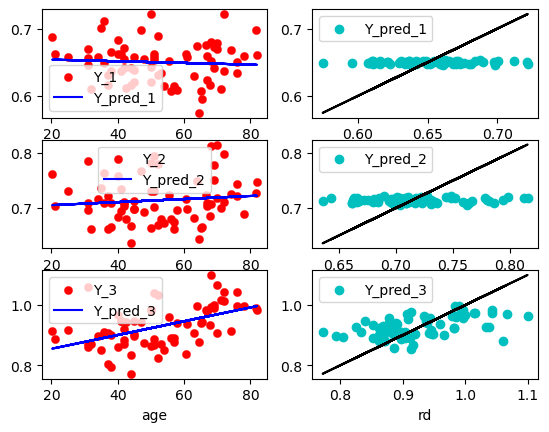

lh_superiorparietal
Weights:
[[-1.51960177e-06]] [[0.00070489]] [[0.00293824]]
MSE:
0.0011246210096278058 0.0025146206065533513 0.0061128580467756915
R2:
4.796550462371485e-07 0.04412194333325148 0.2480736959542853


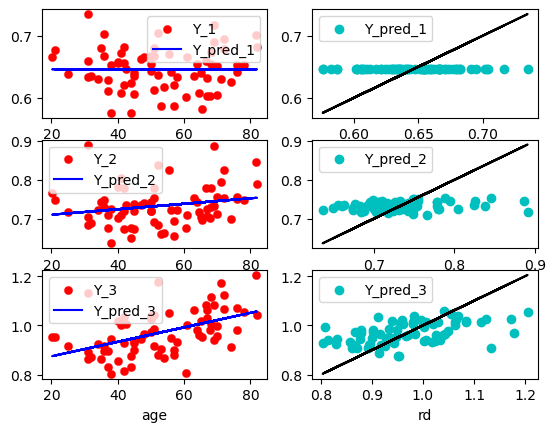

lh_superiortemporal
Weights:
[[-0.00010084]] [[0.00063421]] [[0.00366514]]
MSE:
0.0006124765701452552 0.0014004920024637514 0.0033797586763440624
R2:
0.003863695024214908 0.06287195337745077 0.48145567853810867


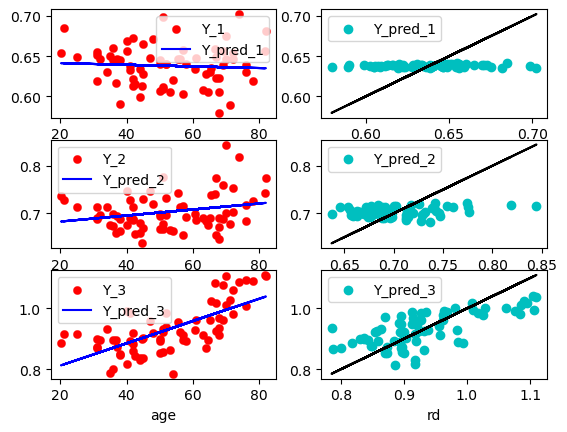

lh_supramarginal
Weights:
[[0.00016988]] [[0.00093191]] [[0.00395261]]
MSE:
0.0009160846381023467 0.0014204718551437156 0.0038692825419091056
R2:
0.007305703748096359 0.12497130000979173 0.4853903031950708


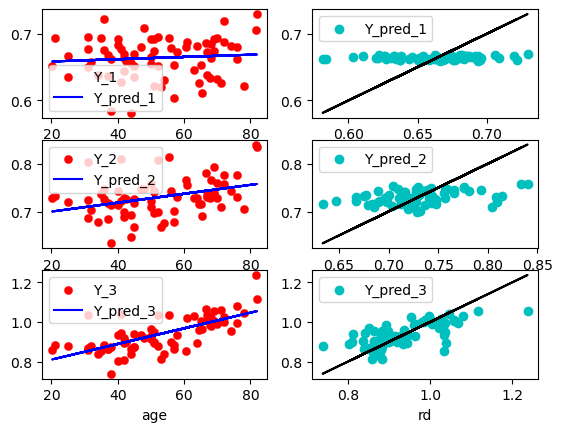

lh_frontalpole
lh_temporalpole
lh_transversetemporal
Weights:
[[-0.00062277]] [[-0.000259]] [[0.00449058]]
MSE:
0.0007668125521911479 0.002635328567768216 0.007096854399853528
R2:
0.10566886088546301 0.005910952444169948 0.3989539125298247


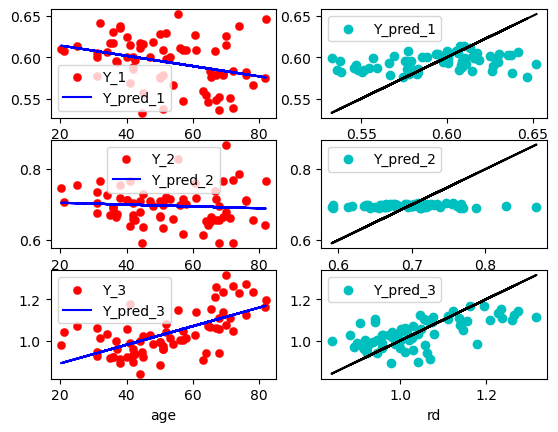

lh_insula
Weights:
[[0.00037466]] [[0.00057331]] [[0.00298114]]
MSE:
0.0009156338626522148 0.0010301124316130904 0.0037887034008955373
R2:
0.034573502857138116 0.06936536914377223 0.35398882965800726


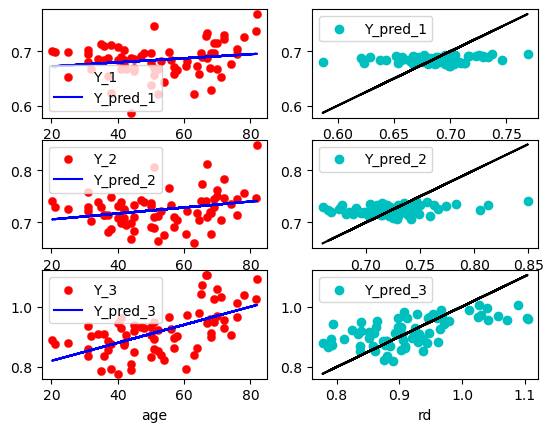

In [12]:
# For left hemisphere
for region in region_list:
    print('lh_' + region)
    Y_1 = left_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = left_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = left_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()


rh_bankssts
Weights:
[[0.00029785]] [[0.00072299]] [[0.00390133]]
MSE:
0.0009157047430474012 0.00129480680488674 0.004782613966491771
R2:
0.022131123641181305 0.08617730506167964 0.42641610282815345


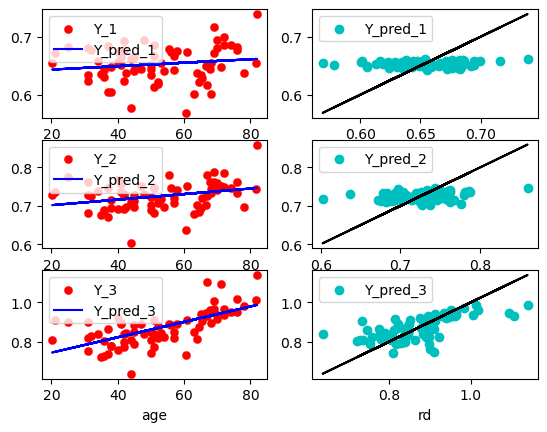

rh_caudalanteriorcingulate
Weights:
[[-0.0003478]] [[0.00036183]] [[0.00222493]]
MSE:
0.0013787787226016619 0.0019241904223740475 0.00392375572604708
R2:
0.020082822198403738 0.015645754222218256 0.2276303446702712


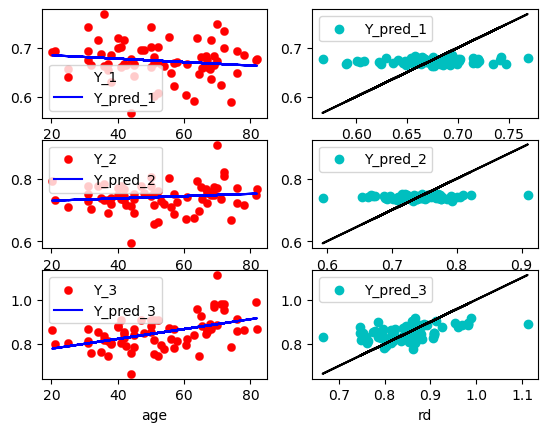

rh_caudalmiddlefrontal
Weights:
[[-0.00047943]] [[-0.00026544]] [[0.00292358]]
MSE:
0.0009487939000703983 0.0014146873499628395 0.003112080807697202
R2:
0.05356140774468254 0.011500348484715373 0.3908334190151985


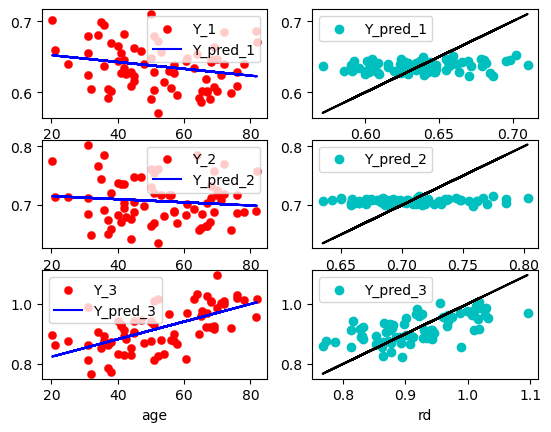

rh_cuneus
Weights:
[[3.36422878e-05]] [[0.00101658]] [[0.00421561]]
MSE:
0.0011472912000230601 0.002751182352979956 0.00702011020186393
R2:
0.0002303950524825682 0.08067032948297848 0.371607592032447


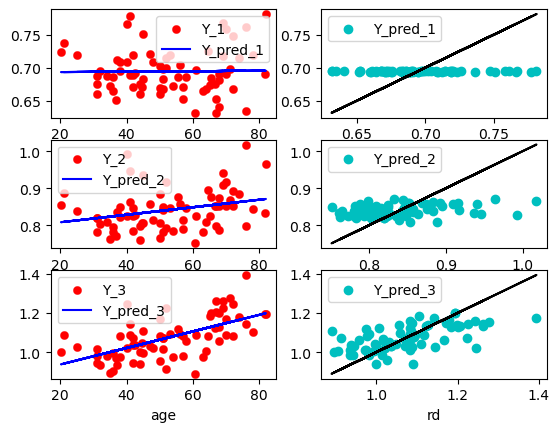

rh_entorhinal
Weights:
[[0.00069095]] [[0.0016831]] [[0.00320625]]
MSE:
0.003384945144251519 0.005481755619088586 0.009020074149294106
R2:
0.031896390243571826 0.10771568256423769 0.2102558403899727


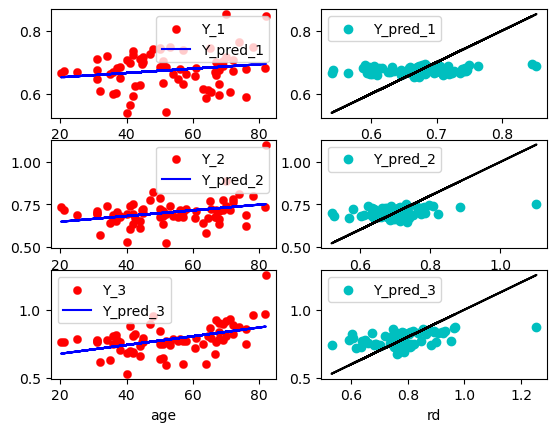

rh_fusiform
Weights:
[[0.00061708]] [[0.00156983]] [[0.00452415]]
MSE:
0.001015309347762896 0.0016868590399340855 0.004517768103072689
R2:
0.08055464255748856 0.25444021811853146 0.5141724369144074


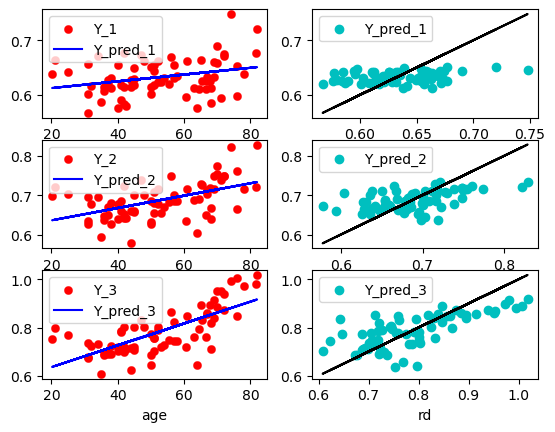

rh_inferiorparietal
Weights:
[[0.00010251]] [[0.00061173]] [[0.00373541]]
MSE:
0.0006439416252665331 0.0008804205304402771 0.002786711677214804
R2:
0.0037972860319396284 0.09032248411403343 0.5390993119778715


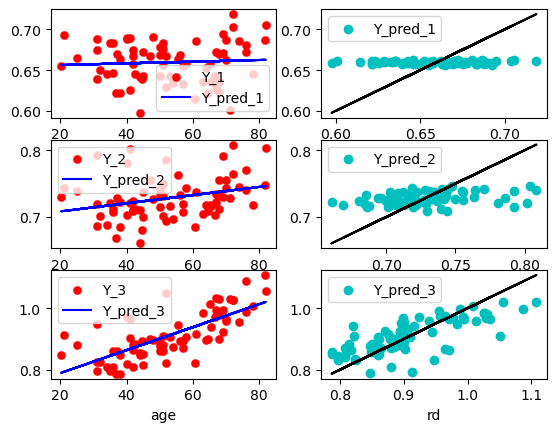

rh_inferiortemporal
Weights:
[[0.00089108]] [[0.00134963]] [[0.00286657]]
MSE:
0.0012234580926216898 0.0019529490573549587 0.003989605497590496
R2:
0.13164899316768863 0.17890008645018252 0.32484426624920004


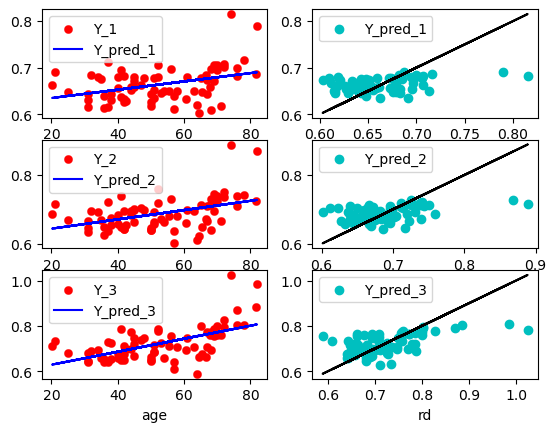

rh_isthmuscingulate
Weights:
[[0.00090688]] [[0.00183392]] [[0.00367974]]
MSE:
0.001502110198372937 0.0030800540840083524 0.006342293655871677
R2:
0.11339794862791486 0.2032390410074233 0.3327681178466467


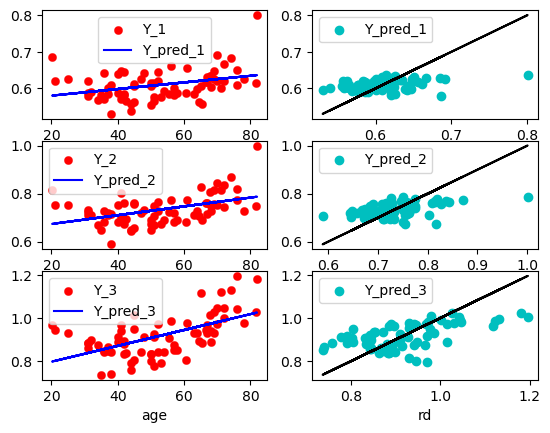

rh_lateraloccipital
Weights:
[[0.00092414]] [[0.00166352]] [[0.00320004]]
MSE:
0.0012301676592383576 0.0024502718566891163 0.00799825327231946
R2:
0.1395444865406782 0.20875188369264408 0.23022587599135935


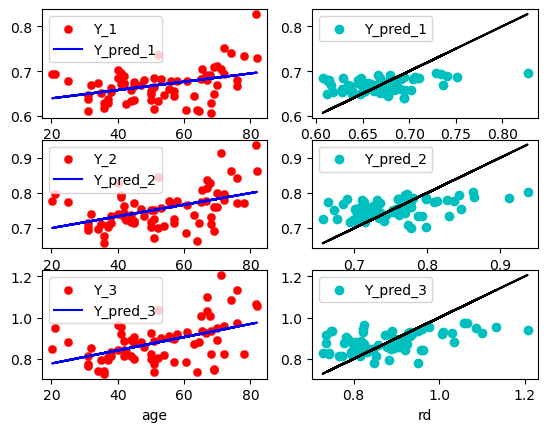

rh_lateralorbitofrontal
rh_lingual
Weights:
[[0.00085737]] [[0.00223583]] [[0.00492625]]
MSE:
0.0019699023676241077 0.0035324367537100413 0.007685685605871349
R2:
0.08018125369086881 0.24844954785854523 0.42449664086951167


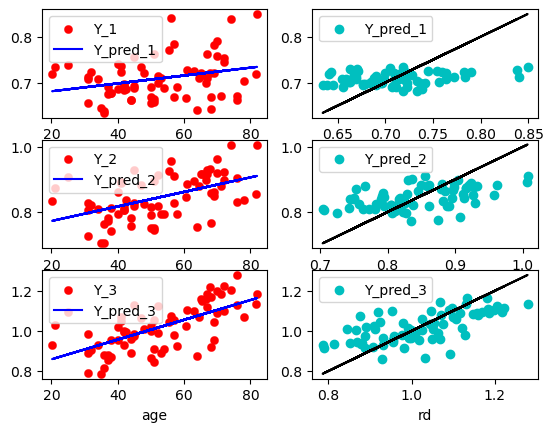

rh_medialorbitofrontal
Weights:
[[0.00146618]] [[0.00191052]] [[0.00288682]]
MSE:
0.00224234160168061 0.0025184110208710513 0.0035401793065478492
R2:
0.18297270757182882 0.2529349331144435 0.35479985447783324


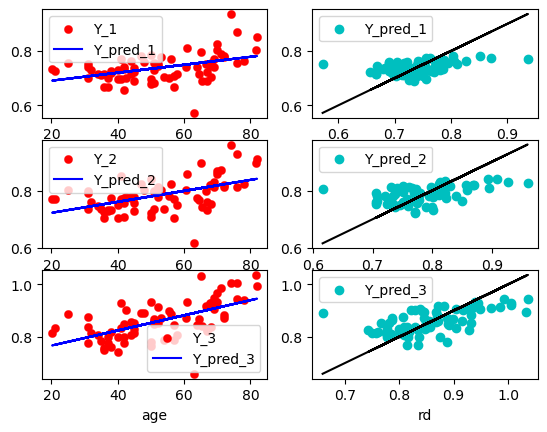

rh_middletemporal
Weights:
[[0.00050389]] [[0.00105539]] [[0.00369555]]
MSE:
0.000994973919527593 0.0013498591634830027 0.003032781772689712
R2:
0.056259592163901306 0.1616079956958476 0.512657036327671


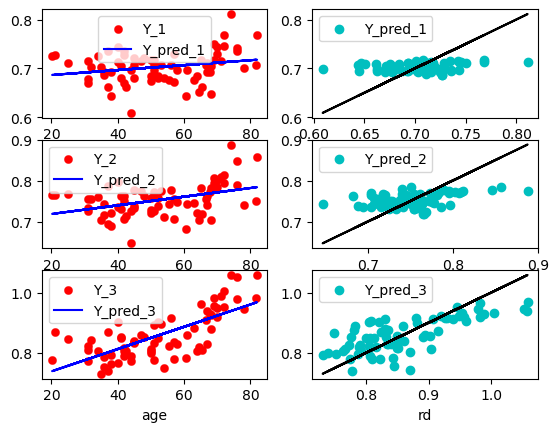

rh_parahippocampal
Weights:
[[0.00088389]] [[0.00155585]] [[0.00351811]]
MSE:
0.0019501485035954421 0.0033417966053669638 0.004693412440253599
R2:
0.08557669240182009 0.14472278924175153 0.38120195047970007


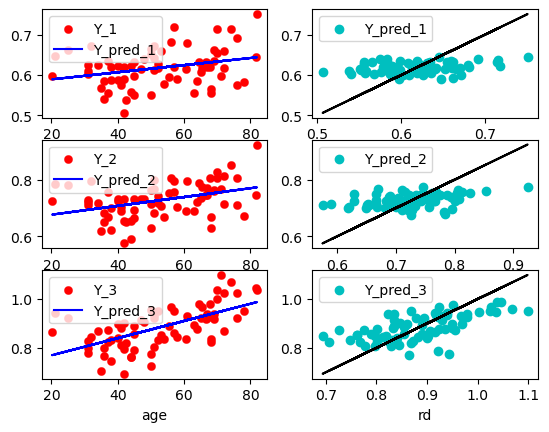

rh_paracentral
Weights:
[[0.00021176]] [[0.00055246]] [[0.0030487]]
MSE:
0.0011064921966040145 0.002135812560637906 0.00689737155298588
R2:
0.009378101042921583 0.032304297364811885 0.2394225279677008


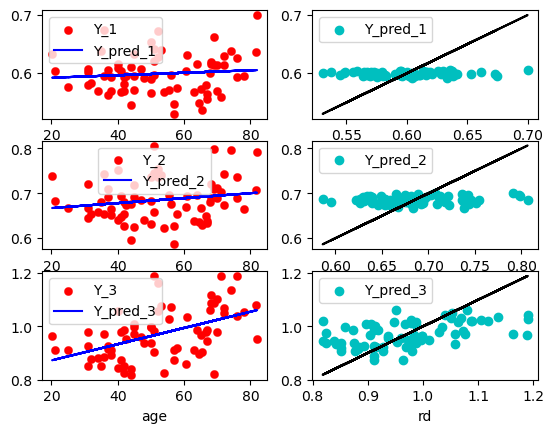

rh_parsopercularis
Weights:
[[9.63951677e-05]] [[0.00041564]] [[0.00279345]]
MSE:
0.0007662967631088544 0.0011839256911374083 0.0032196769553624197
R2:
0.0028246257886472836 0.03296296836432999 0.3614996935121628


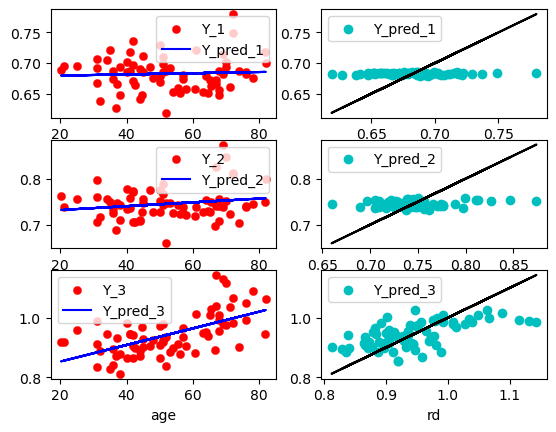

rh_parsorbitalis
Weights:
[[0.00039532]] [[0.0006943]] [[0.00306954]]
MSE:
0.001045254249316634 0.001912484864236183 0.004056194128216869
R2:
0.03374784070773906 0.055606775345088955 0.35175640943994957


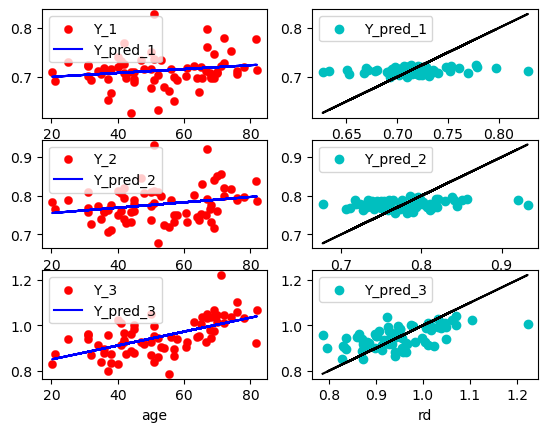

rh_parstriangularis
Weights:
[[0.00013134]] [[0.00057224]] [[0.00298979]]
MSE:
0.0008775930584590868 0.0014302689790205868 0.004629775583090255
R2:
0.004570794105277276 0.05076809920163505 0.3108299221773624


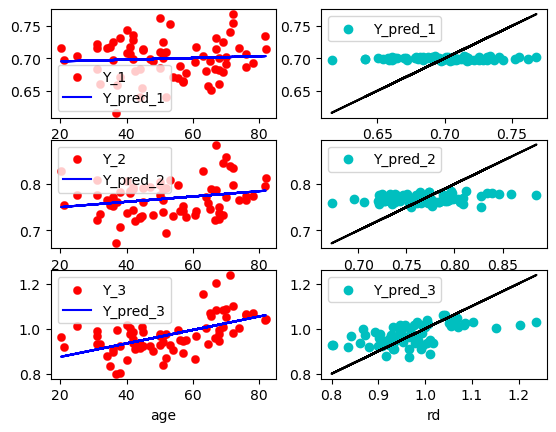

rh_pericalcarine
Weights:
[[0.00114738]] [[0.00236569]] [[0.00440288]]
MSE:
0.002507097293337998 0.003960477065433294 0.008918815036023865
R2:
0.10926278973429082 0.2481765028327566 0.33675605938242825


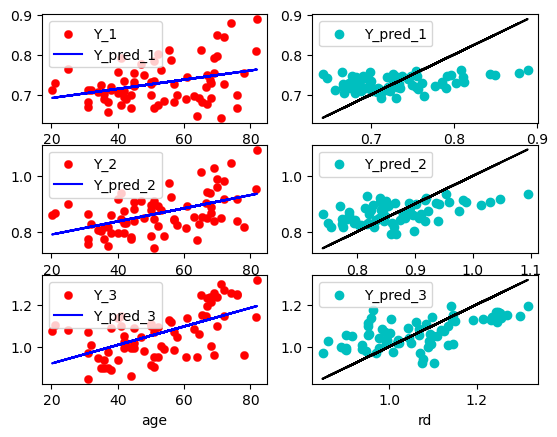

rh_postcentral
Weights:
[[-0.00069266]] [[-6.19889594e-05]] [[0.00263243]]
MSE:
0.0015168601380857014 0.0028286699188317973 0.004459181807311155
R2:
0.06880455366033222 0.00031723745992806585 0.26633686272512125


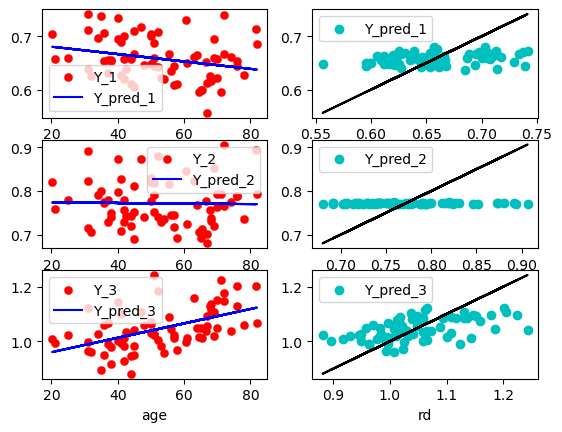

rh_posteriorcingulate
Weights:
[[-0.00030434]] [[0.00026457]] [[0.00288816]]
MSE:
0.0008709982095592028 0.0011047409217339026 0.0037485397211585434
R2:
0.024238637078288217 0.014585128575501205 0.34202868354312177


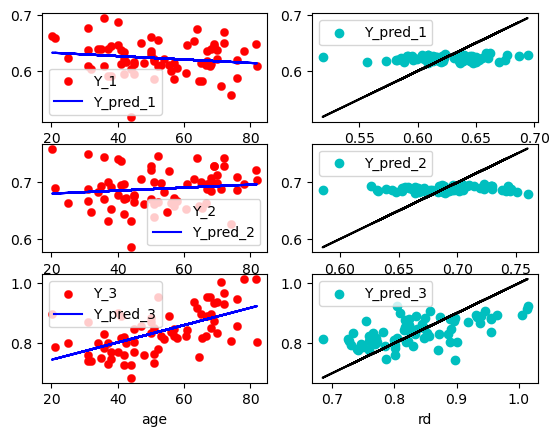

rh_precentral
Weights:
[[-0.00060319]] [[-0.0003517]] [[0.00262283]]
MSE:
0.0007220546395534406 0.0010475900899460113 0.005405770031737334
R2:
0.10531345670393522 0.02684217582088766 0.229152950918318


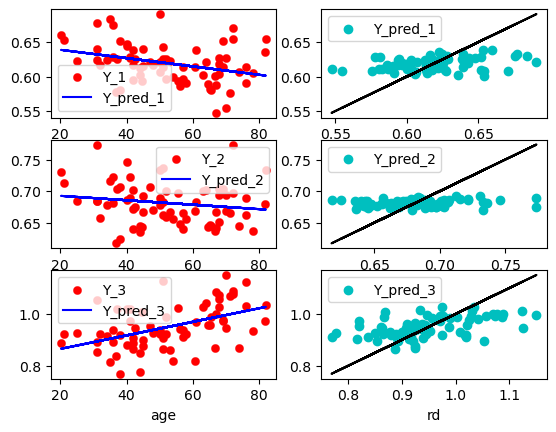

rh_precuneus
Weights:
[[0.00023318]] [[0.00093508]] [[0.00367721]]
MSE:
0.0008303611553112641 0.001398158777456307 0.0038363239066632982
R2:
0.015065688951377054 0.1274681163455963 0.45156599185644763


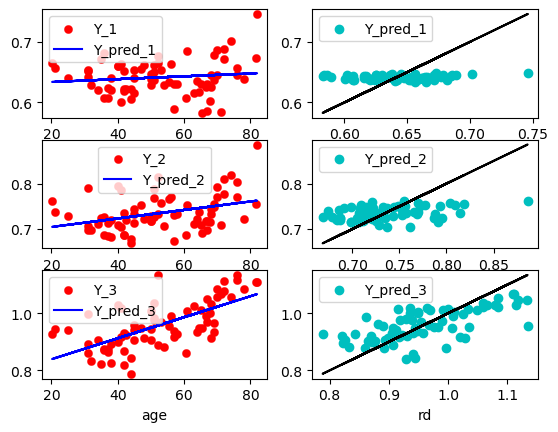

rh_rostralanteriorcingulate
Weights:
[[-0.00012191]] [[0.00030314]] [[0.00218785]]
MSE:
0.0017902069446556178 0.002358022708244156 0.0037652590938224996
R2:
0.001935607441768794 0.009021236826333268 0.22897313987357315


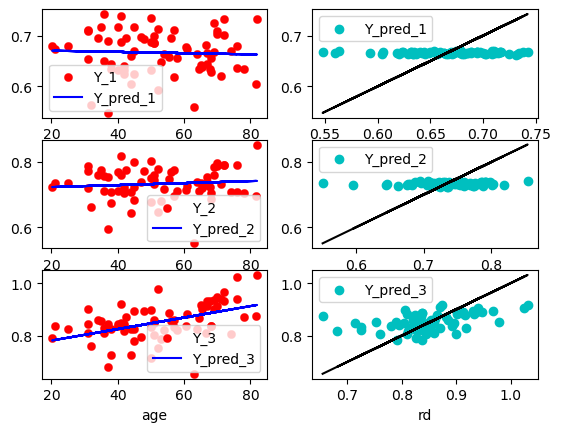

rh_rostralmiddlefrontal
Weights:
[[-8.04954879e-05]] [[0.00032433]] [[0.00283177]]
MSE:
0.0007704130533311868 0.0012331817805853501 0.003231469879256221
R2:
0.0019608431785693714 0.019536975926517486 0.3669621931670013


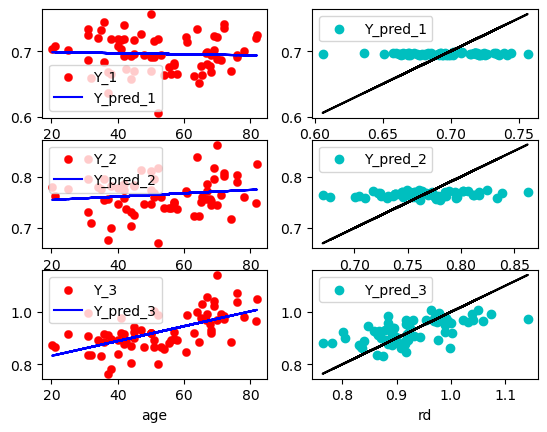

rh_superiorfrontal
Weights:
[[-0.00021925]] [[0.00021707]] [[0.00224887]]
MSE:
0.0008577665827598203 0.0013113973591243726 0.0030433868996592624
R2:
0.012922565218453697 0.008323946710616648 0.27963848242211686


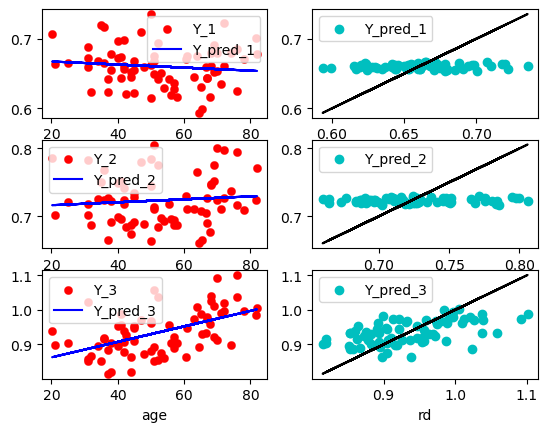

rh_superiorparietal
Weights:
[[-0.00017967]] [[0.00036484]] [[0.00246871]]
MSE:
0.0010240529969957602 0.002008956123215279 0.005429057637264806
R2:
0.00730982101157196 0.015241755127293533 0.20775523152780895


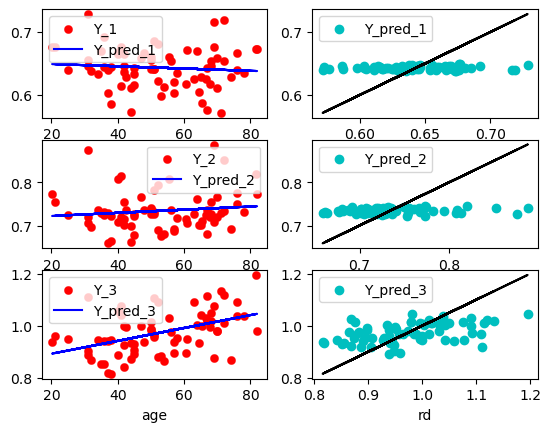

rh_superiortemporal
Weights:
[[0.00035222]] [[0.00095904]] [[0.00392819]]
MSE:
0.0011199199118922748 0.0018266310348164071 0.0038085760572813356
R2:
0.025224796794248272 0.10524585219852611 0.48624485355977565


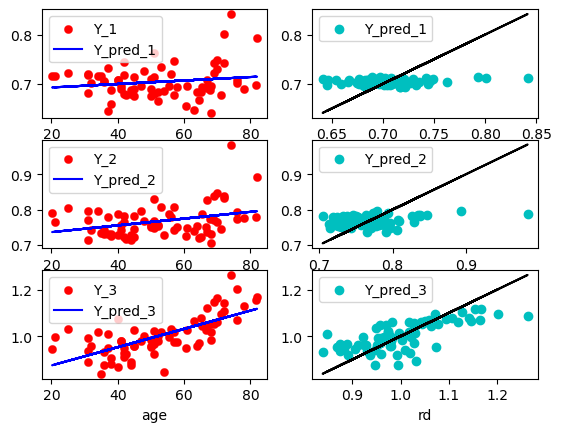

rh_supramarginal
Weights:
[[-4.99985918e-06]] [[0.00067474]] [[0.00389509]]
MSE:
0.0007581966868375191 0.0011034569323547763 0.00283199535281356
R2:
7.702046878055313e-06 0.08790873991241865 0.5558442527260603


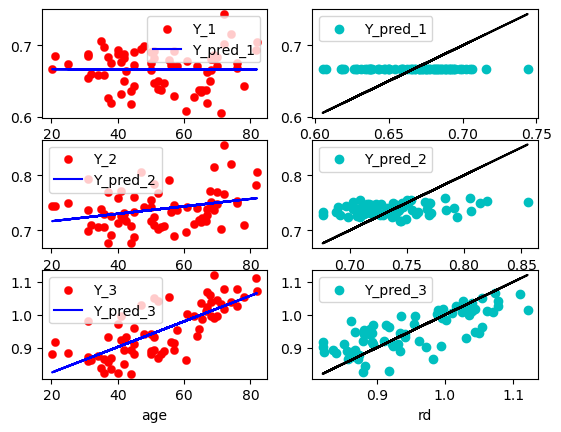

rh_frontalpole
rh_temporalpole
rh_transversetemporal
Weights:
[[-0.00027723]] [[-0.00016656]] [[0.0054158]]
MSE:
0.0011007057049214452 0.0038425520093014775 0.010046669651957987
R2:
0.016049247698674995 0.0016836484017276332 0.4054664607782459


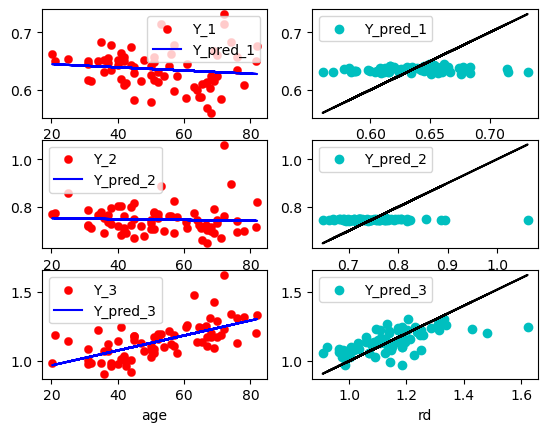

rh_insula
Weights:
[[0.00080714]] [[0.00104156]] [[0.00336364]]
MSE:
0.0012877822575135603 0.0015095518486395265 0.004038928913808465
R2:
0.10568754912302591 0.14374604534987923 0.3955430844387956


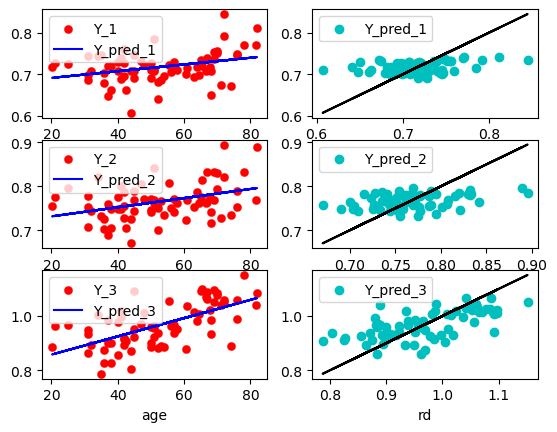

In [11]:
# For right hemisphere
for region in region_list:
    print('rh_' + region)
    Y_1 = right_dic[region][:,0].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_1)
    r2_1 = linear_model.score(X, Y_1)
    weights_1 = linear_model.coef_
    Y_pred_1 = linear_model.predict(X)
    mse_1 = np.mean((Y_pred_1 - Y_1) ** 2)

    Y_2 = right_dic[region][:,1].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_2)
    r2_2 = linear_model.score(X, Y_2)
    weights_2 = linear_model.coef_
    Y_pred_2 = linear_model.predict(X)
    mse_2 = np.mean((Y_pred_2 - Y_2) ** 2)

    Y_3 = right_dic[region][:,2].reshape((-1, 1))
    linear_model = LinearRegression()
    linear_model.fit(X, Y_3)
    r2_3 = linear_model.score(X, Y_3)
    weights_3 = linear_model.coef_
    Y_pred_3 = linear_model.predict(X)
    mse_3 = np.mean((Y_pred_3 - Y_3) ** 2)

    if r2_1 > 0.2 or r2_2 > 0.2 or r2_3 > 0.2:
        print('Weights:')
        print(weights_1, weights_2, weights_3)
        print('MSE:')
        print(mse_1, mse_2, mse_3)
        print('R2:')
        print(r2_1, r2_2, r2_3)
        plt.subplot(3, 2, 1)
        plt.scatter(X[:,0], Y_1[:,0], label='Y_1', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_1[:,0], label='Y_pred_1', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 2)
        plt.scatter(Y_1[:,0], Y_pred_1[:,0], label='Y_pred_1', color='c')
        plt.plot(Y_1[:,0], Y_1[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 3)
        plt.scatter(X[:,0], Y_2[:,0], label='Y_2', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_2[:,0], label='Y_pred_2', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 4)
        plt.scatter(Y_2[:,0], Y_pred_2[:,0], label='Y_pred_2', color='c')
        plt.plot(Y_2[:,0], Y_2[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.subplot(3, 2, 5)
        plt.scatter(X[:,0], Y_3[:,0], label='Y_3', color='r', linewidths=0.2)
        plt.plot(X[:,0], Y_pred_3[:,0], label='Y_pred_3', color='b')
        plt.legend()
        plt.xlabel('age')
        plt.subplot(3, 2, 6)
        plt.scatter(Y_3[:,0], Y_pred_3[:,0], label='Y_pred_3', color='c')
        plt.plot(Y_3[:,0], Y_3[:,0], color='k')
        plt.legend()
        plt.xlabel(type)
        plt.show()
